In [3]:
from ml_toolkit.eda import *

In [4]:
from pathlib import Path
import pandas as pd

TARGET_COLUMN = "default_flag"
ID_COLUMN = "user_id"

RAW_DATA_PATH = Path("../data/raw/data.csv")

df = pd.read_csv(RAW_DATA_PATH)

In [5]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns.to_list()

categorical_columns = df.select_dtypes(exclude=["int64", "float64"]).columns.to_list()

In [6]:
target_distribution(df, TARGET_COLUMN)

,count,percentage
default_flag,,
0,6305,60.947318
1,4040,39.052682


In [7]:
zero_percentage(df, numeric_columns)

,feature,zero_pct
0,default_flag,60.947318
1,missed_payments,35.804737
2,repayment_delay_days,11.783470
3,risk_score,0.086999


In [8]:
iqr_outlier_summary(df, numeric_columns )

,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,debt_to_income_ratio,0.080187,0.2683,0.188113,-0.201983,0.55047,57,0.550991
1,risk_score,153.600000,250.8000,97.200000,7.800000,396.60000,31,0.299662
2,monthly_income,12207.020000,55276.9300,43069.910000,-52397.845000,119881.79500,25,0.241663
3,missed_payments,0.000000,2.0000,2.000000,-3.000000,5.00000,8,0.077332
4,repayment_delay_days,2.000000,14.0000,12.000000,-16.000000,32.00000,1,0.009667
5,credit_score,332.000000,547.0000,215.000000,9.500000,869.50000,0,0.000000
6,user_id,2587.000000,7759.0000,5172.000000,-5171.000000,15517.00000,0,0.000000
7,age,28.000000,49.0000,21.000000,-3.500000,80.50000,0,0.000000
8,purchase_amount,2990.720000,5000.0000,2009.280000,-23.200000,8013.92000,0,0.000000
9,bnpl_installments,3.000000,9.0000,6.000000,-6.000000,18.00000,0,0.000000


In [9]:
categorical_target_rate(df, "location" , TARGET_COLUMN )

,location,count,positives,target_rate,target_rate_pct
0,Germany,1760,709,0.402841,40.284091
1,UK,1664,658,0.395433,39.543269
2,Australia,1722,670,0.389082,38.908246
3,Canada,1740,675,0.387931,38.793103
4,USA,1736,672,0.387097,38.709677
5,India,1723,656,0.380731,38.073128


In [10]:
categorical_target_rate(df, "employment_type" , TARGET_COLUMN )

,employment_type,count,positives,target_rate,target_rate_pct
0,Unemployed,2632,1281,0.486702,48.670213
1,Student,2531,1229,0.485579,48.557882
2,Salaried,2632,861,0.327128,32.712766
3,Self-Employed,2550,669,0.262353,26.235294


In [11]:
numeric_target_rate_by_quantile(df, "missed_payments", TARGET_COLUMN, bins=10)

,bin,count,positives,target_rate,target_rate_pct
0,"(-0.001, 1.0]",7541,2469,0.327410,32.741016
1,"(1.0, 2.0]",1969,877,0.445404,44.540376
2,"(2.0, 7.0]",835,694,0.831138,83.113772


In [12]:
corr_matrix = correlation_matrix(df, numeric_columns, method="pearson")

In [13]:
print(high_correlation_pairs(corr_matrix, threshold=0.65))

              feature_1             feature_2  correlation
0        monthly_income          credit_score     0.960989
1          credit_score            risk_score    -0.891544
2        monthly_income            risk_score    -0.781487
3  repayment_delay_days       missed_payments     0.713719
4        monthly_income  debt_to_income_ratio    -0.700067
5          credit_score  debt_to_income_ratio    -0.669564


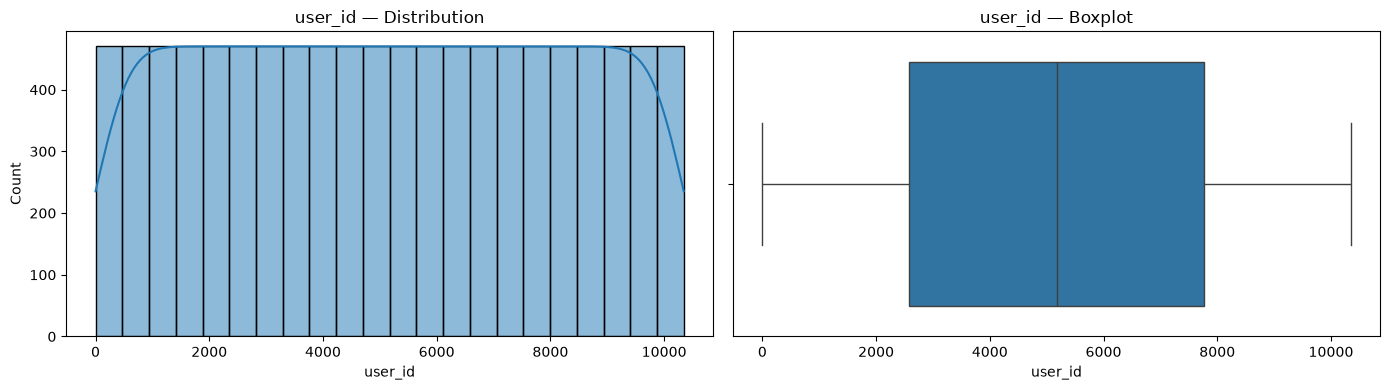

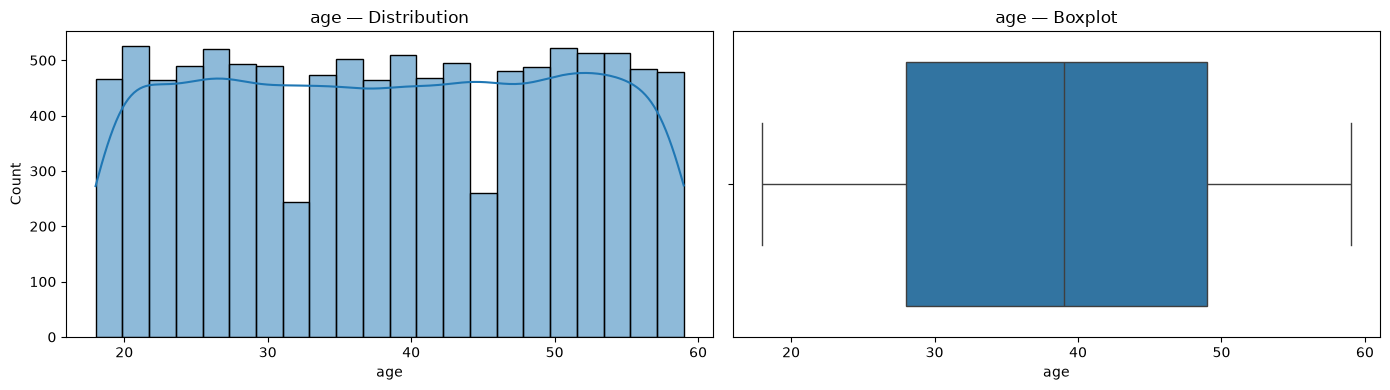

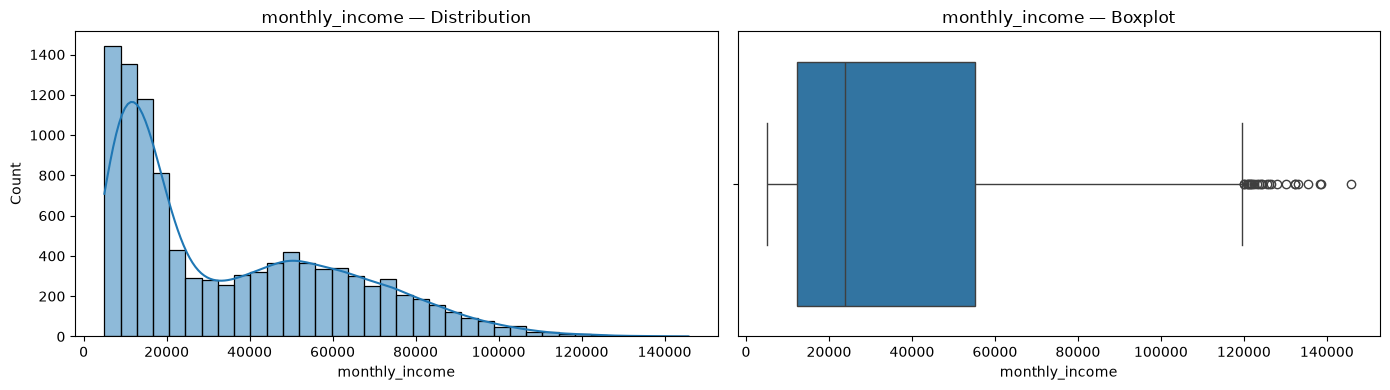

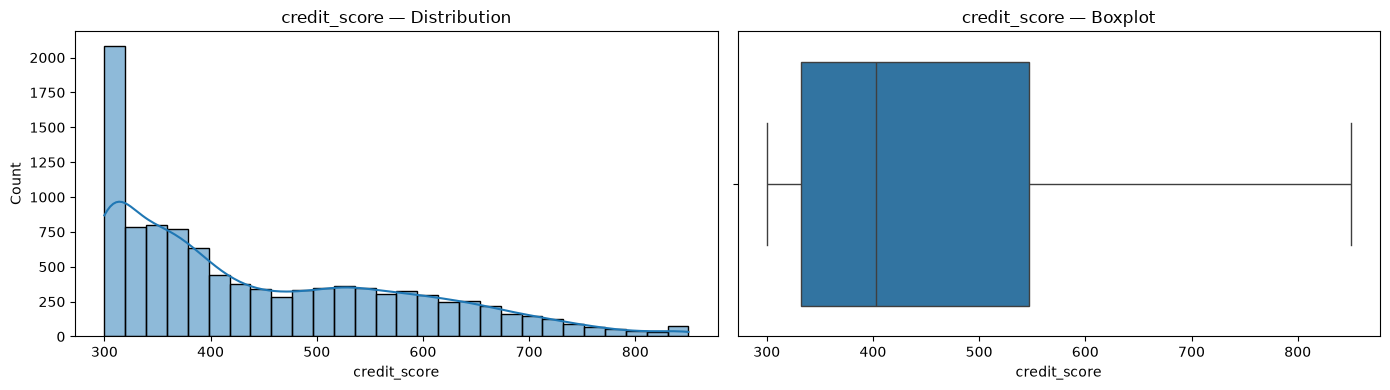

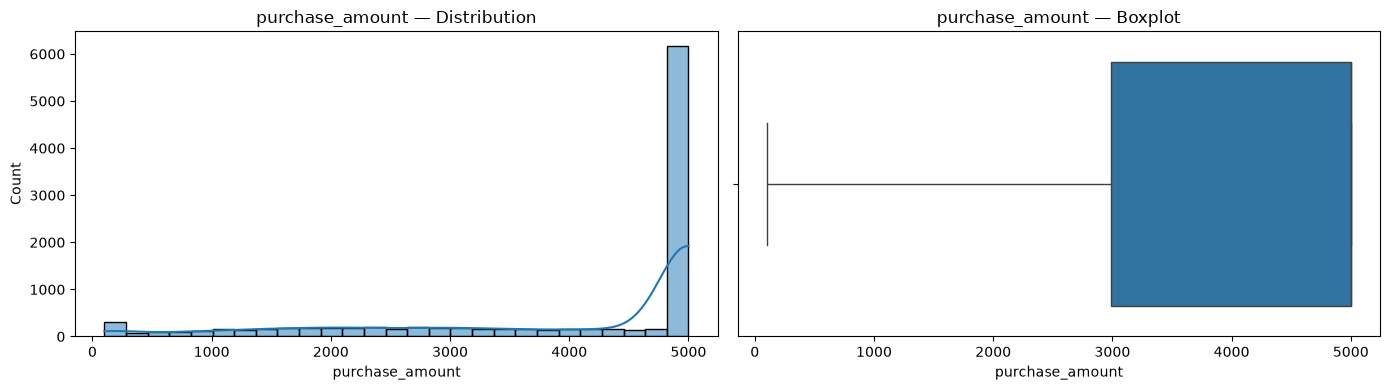

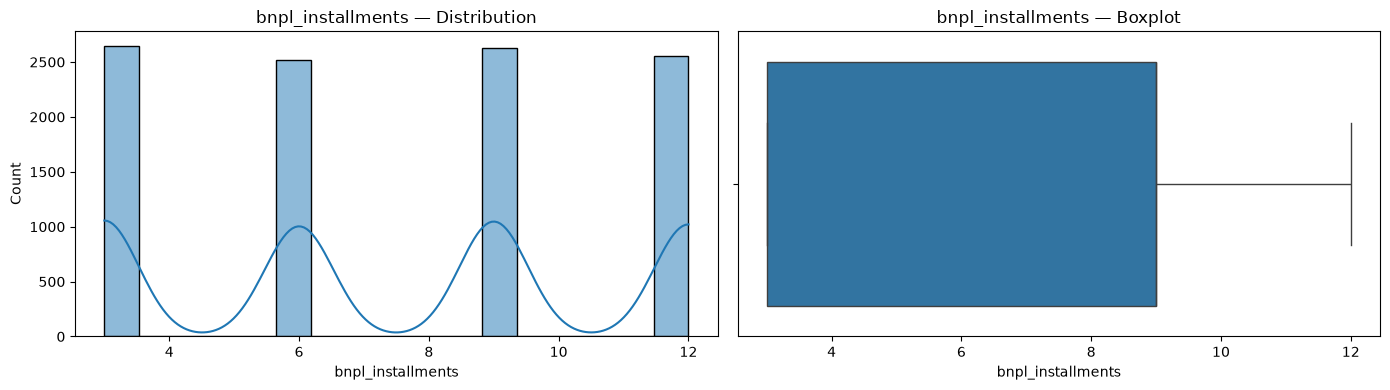

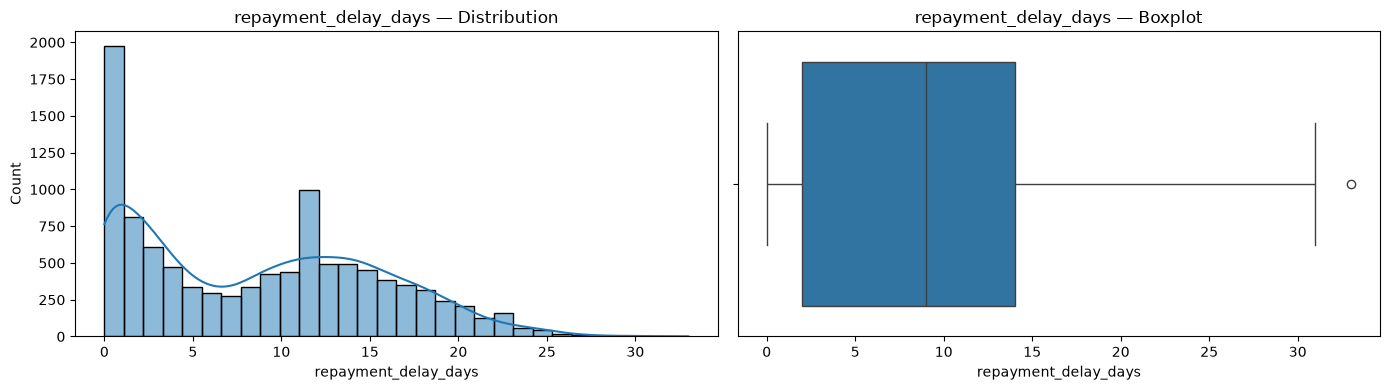

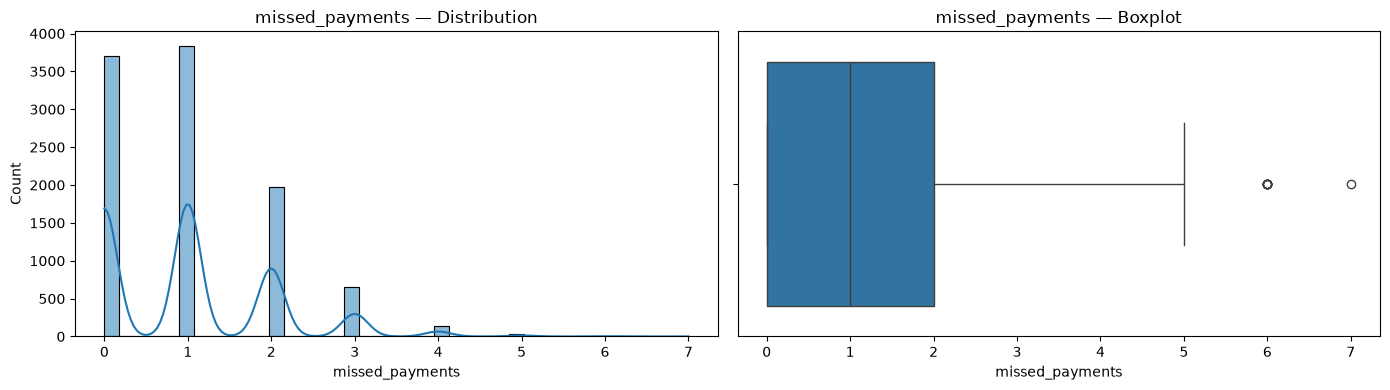

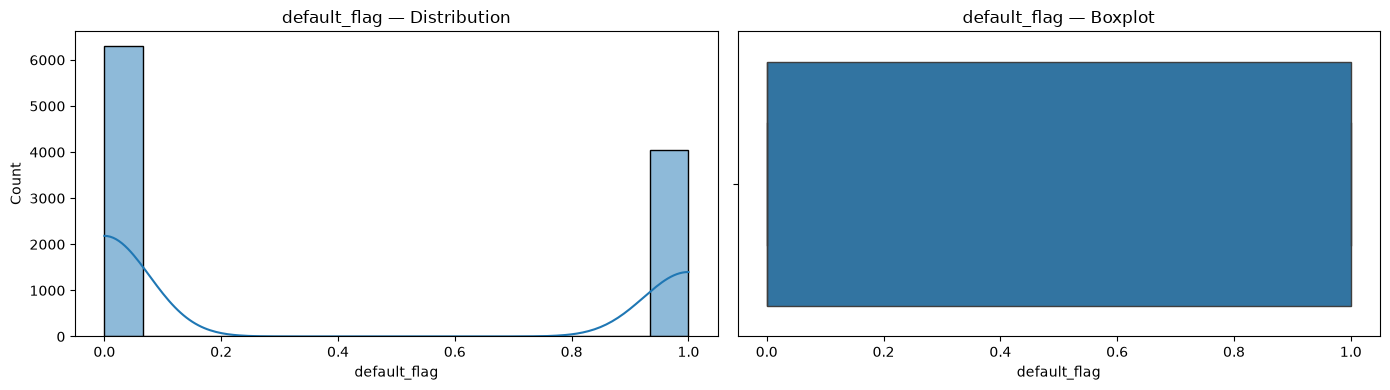

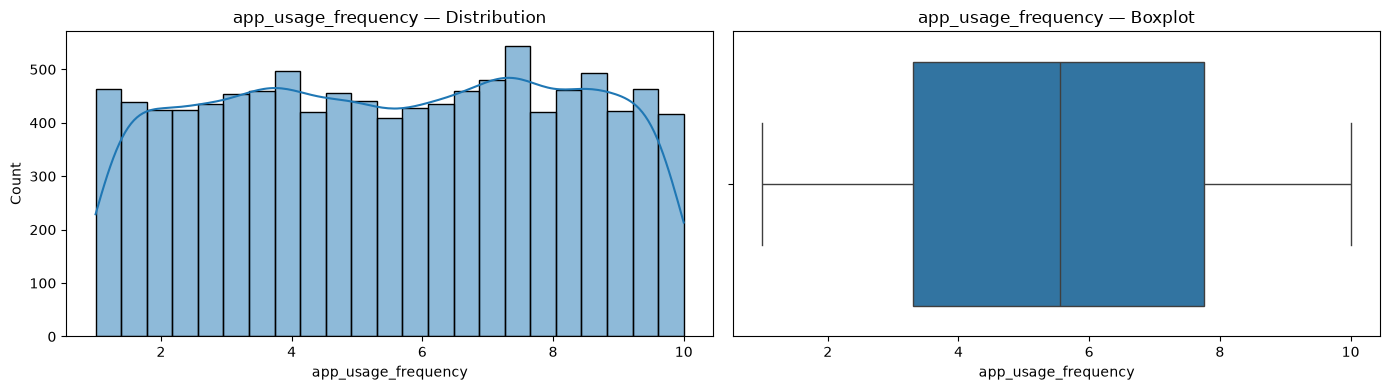

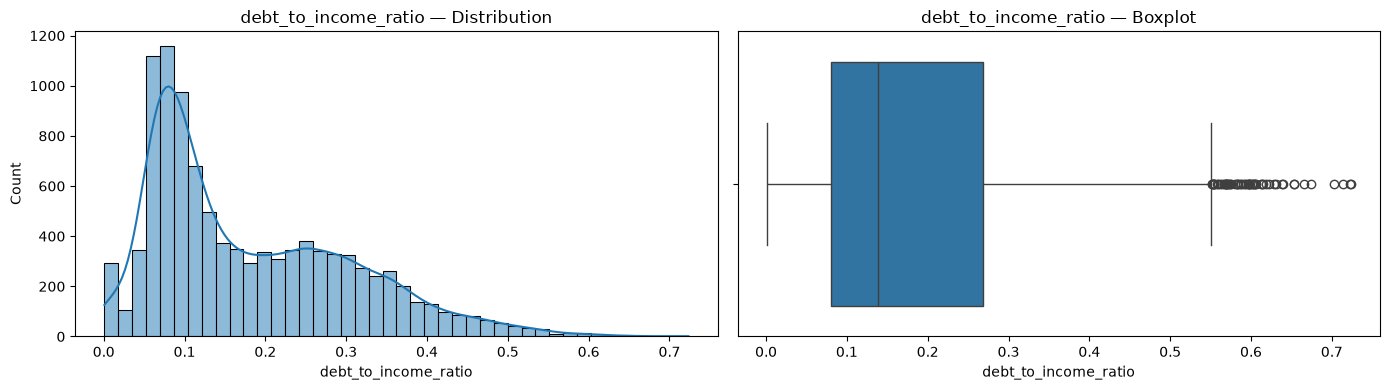

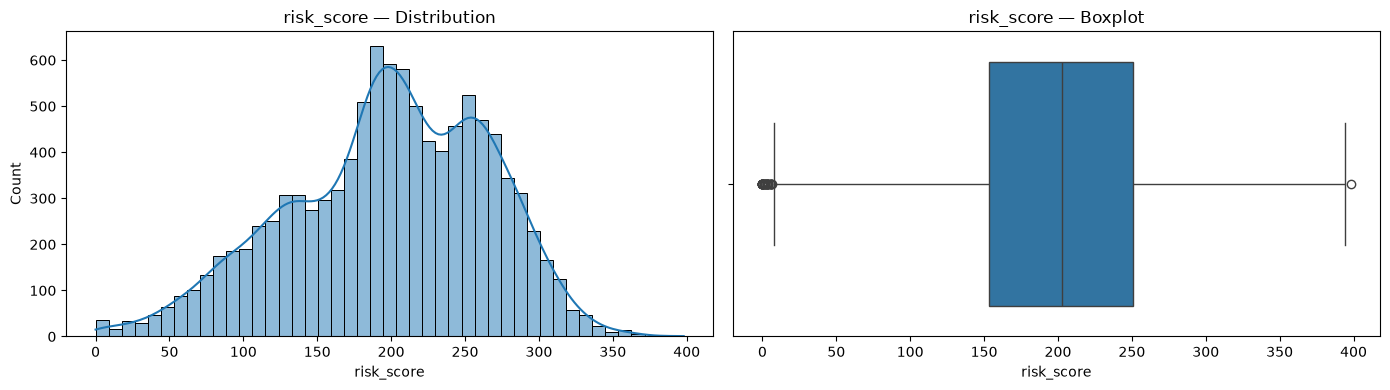

In [14]:
for col in numeric_columns:
    plot_numeric_distribution(df, col)

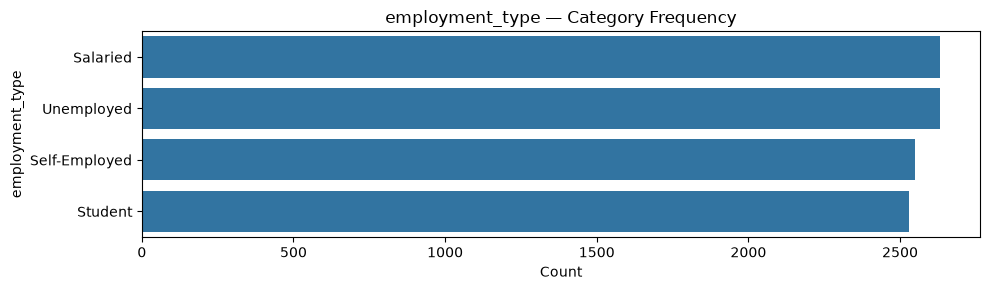

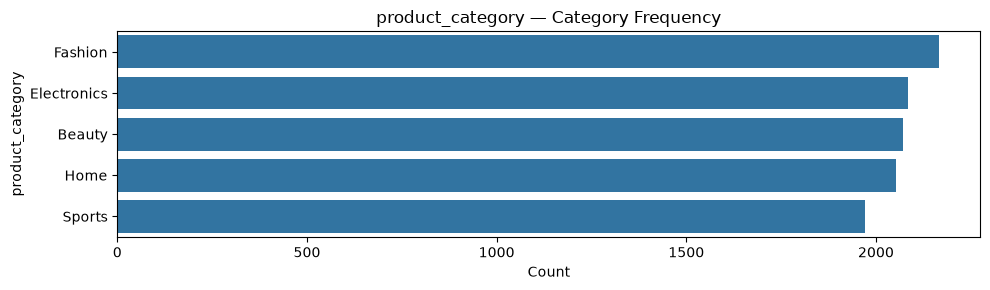

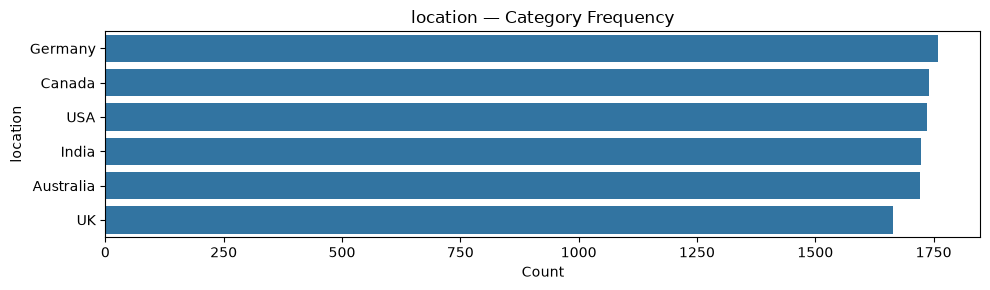

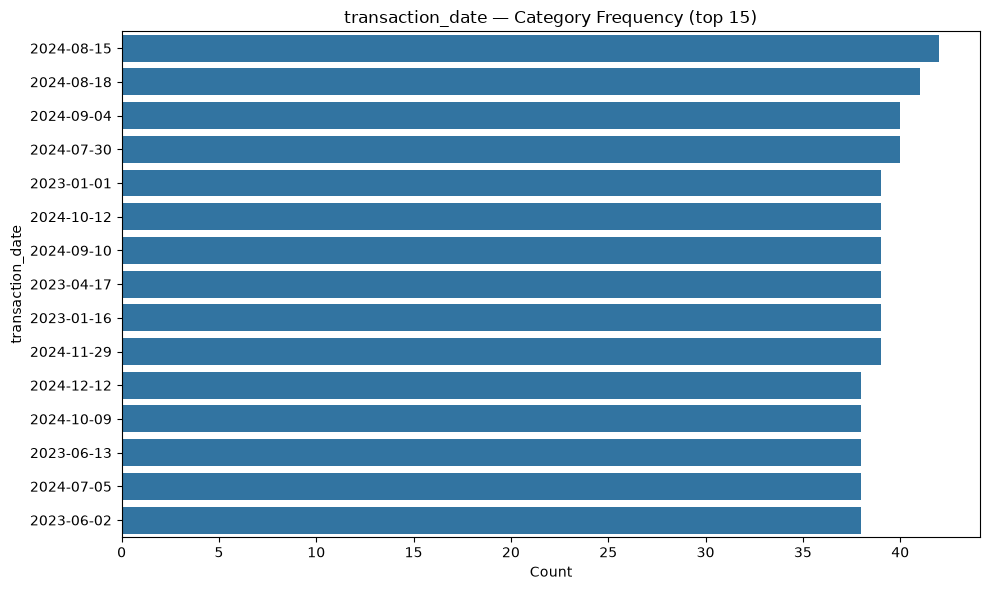

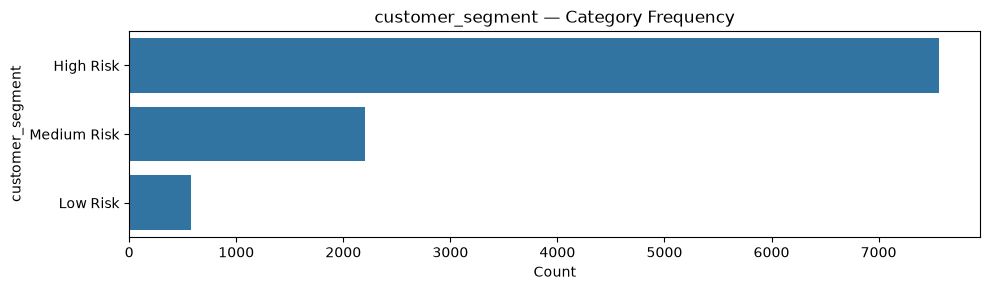

In [15]:
for col in categorical_columns: plot_categorical_distribution(df, col, top_n=15)

In [16]:
for col in categorical_columns:
    print(f"{col} - {df[col].unique()}")

employment_type - <ArrowStringArray>
['Salaried', 'Student', 'Self-Employed', 'Unemployed']
Length: 4, dtype: str
product_category - <ArrowStringArray>
['Electronics', 'Fashion', 'Sports', 'Home', 'Beauty']
Length: 5, dtype: str
location - <ArrowStringArray>
['Australia', 'USA', 'Germany', 'India', 'Canada', 'UK']
Length: 6, dtype: str
transaction_date - <ArrowStringArray>
['2023-06-10', '2024-10-07', '2023-04-05', '2023-06-24', '2024-10-19',
 '2024-08-29', '2024-08-21', '2024-11-17', '2024-11-14', '2023-06-09',
 ...
 '2024-11-24', '2024-08-05', '2023-03-09', '2024-12-16', '2024-10-04',
 '2024-07-21', '2023-04-01', '2023-01-25', '2024-09-12', '2024-07-06']
Length: 365, dtype: str
customer_segment - <ArrowStringArray>
['Medium Risk', 'High Risk', 'Low Risk']
Length: 3, dtype: str


In [17]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

def create_split_reference(df: pd.DataFrame, id_col: str, output_path: str, test_size: float = 0.2, random_state: int = 42) -> None:
    """
    Creates a 2-column Parquet reference file mapping unique IDs to their train/test split.
    """
    # 1. Get unique IDs (important if your dataset has multiple rows per ID)
    unique_ids = df[id_col].dropna().unique()
    
    # 2. Perform the split purely on the IDs
    train_ids, test_ids = train_test_split(unique_ids, test_size=test_size, random_state=random_state)
    
    # 3. Create mapping DataFrames
    train_ref = pd.DataFrame({
        id_col: train_ids,
        'split': 'train'
    })
    
    test_ref = pd.DataFrame({
        id_col: test_ids,
        'split': 'test'
    })
    
    # 4. Combine and save
    split_ledger = pd.concat([train_ref, test_ref], ignore_index=True)
    
    # Ensure directory exists
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    # Save as parquet
    split_ledger.to_parquet(output_path, index=False, engine='pyarrow')
    print(f"Split reference saved to {output_path} with {len(train_ids)} train and {len(test_ids)} test IDs.")


In [18]:
create_split_reference(df=df, id_col='user_id', output_path='../data/metadata/split_ledger.parquet')

Split reference saved to ../data/metadata/split_ledger.parquet with 8276 train and 2069 test IDs.


In [20]:
df.to_parquet("../data/processed/02_eda_data.parquet")

In [ ]:
DROP_COLUMNS = [
    "user_id",
    "repayment_delay_days",
    "risk_score",
    "customer_segment"
]

In [38]:
SAFE_FEATURES = [
    "age",
    "employment_type",
    "monthly_income",
    "credit_score",
    "purchase_amount",
    "product_category",
    "bnpl_installments",
    "app_usage_frequency",
    "location",
    "transaction_date",
    "debt_to_income_ratio",
]


In [39]:
TARGET = "default_flag"


In [40]:
df["transaction_date"] = pd.to_datetime(
    df["transaction_date"],
    errors="raise"
)


In [41]:
df["transaction_date"].dtype


dtype('<M8[us]')

In [42]:
df["transaction_year"] = df["transaction_date"].dt.year
df["transaction_month"] = df["transaction_date"].dt.month
df["transaction_dayofweek"] = df["transaction_date"].dt.dayofweek

df["is_weekend"] = (
    df["transaction_dayofweek"] >= 5
).astype(int)
